In [ ]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np


In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
])
train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, transform=transform, download=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

100%|██████████| 170M/170M [00:12<00:00, 13.1MB/s]


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class DenoisingAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 3, stride=2, padding=1),  # 32x16x16
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1),  # 64x8x8
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 128, 3, stride=2, padding=1),  # 128x4x4
            nn.BatchNorm2d(128),
            nn.ReLU()
        )
        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 3, stride=2, padding=1, output_padding=1),  # 64x8x8
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=1),  # 32x16x16
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 3, stride=2, padding=1, output_padding=1),   # 3x32x32
            nn.Tanh()
        )

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)

def compute_accuracy(preds, targets, threshold=0.1):
    return (torch.abs(preds - targets) < threshold).float().mean().item()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = DenoisingAutoencoder().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

def add_noise(imgs, noise_level=0.2):
    noisy = imgs + noise_level * torch.randn_like(imgs)
    return torch.clamp(noisy, 0., 1.)

for epoch in range(40):
    model.train()
    total_loss = 0
    total_acc = 0
    for clean_imgs, _ in train_loader:
        clean_imgs = clean_imgs.to(device)
        noisy_imgs = add_noise(clean_imgs)

        outputs = model(noisy_imgs)
        loss = criterion(outputs, clean_imgs)
        acc = compute_accuracy(outputs, clean_imgs)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_acc += acc

    avg_loss = total_loss / len(train_loader)
    avg_acc = total_acc / len(train_loader)
    print(f"Epoch {epoch+1}: Loss = {avg_loss:.4f}, Accuracy = {avg_acc*100:.2f}%")


Epoch 1: Loss = 0.0268, Accuracy = 63.87%
Epoch 2: Loss = 0.0072, Accuracy = 79.81%
Epoch 3: Loss = 0.0061, Accuracy = 82.88%
Epoch 4: Loss = 0.0056, Accuracy = 84.15%
Epoch 5: Loss = 0.0053, Accuracy = 85.03%
Epoch 6: Loss = 0.0051, Accuracy = 85.69%
Epoch 7: Loss = 0.0049, Accuracy = 86.12%
Epoch 8: Loss = 0.0048, Accuracy = 86.49%
Epoch 9: Loss = 0.0048, Accuracy = 86.58%
Epoch 10: Loss = 0.0047, Accuracy = 86.78%
Epoch 11: Loss = 0.0046, Accuracy = 87.06%
Epoch 12: Loss = 0.0046, Accuracy = 87.08%
Epoch 13: Loss = 0.0045, Accuracy = 87.32%
Epoch 14: Loss = 0.0045, Accuracy = 87.52%
Epoch 15: Loss = 0.0044, Accuracy = 87.73%
Epoch 16: Loss = 0.0044, Accuracy = 87.85%
Epoch 17: Loss = 0.0044, Accuracy = 87.91%
Epoch 18: Loss = 0.0043, Accuracy = 88.03%
Epoch 19: Loss = 0.0043, Accuracy = 88.19%
Epoch 20: Loss = 0.0043, Accuracy = 88.15%
Epoch 21: Loss = 0.0043, Accuracy = 88.18%
Epoch 22: Loss = 0.0042, Accuracy = 88.38%
Epoch 23: Loss = 0.0042, Accuracy = 88.39%
Epoch 24: Loss = 0.0

In [ ]:
def evaluate_denoising_autoencoder(model, test_loader, device):
    model.eval()
    total_loss = 0
    total_acc = 0
    with torch.no_grad():
        for clean_imgs, _ in test_loader:
            clean_imgs = clean_imgs.to(device)
            noisy_imgs = add_noise(clean_imgs)

            outputs = model(noisy_imgs)
            loss = criterion(outputs, clean_imgs)
            acc = compute_accuracy(outputs, clean_imgs)

            total_loss += loss.item()
            total_acc += acc

    avg_loss = total_loss / len(test_loader)
    avg_acc = total_acc / len(test_loader)
    print(f"[Test] Loss = {avg_loss:.4f}, Accuracy = {avg_acc*100:.2f}%")


In [ ]:
evaluate_denoising_autoencoder(model, test_loader, device)


[Test] Loss = 0.0039, Accuracy = 89.59%


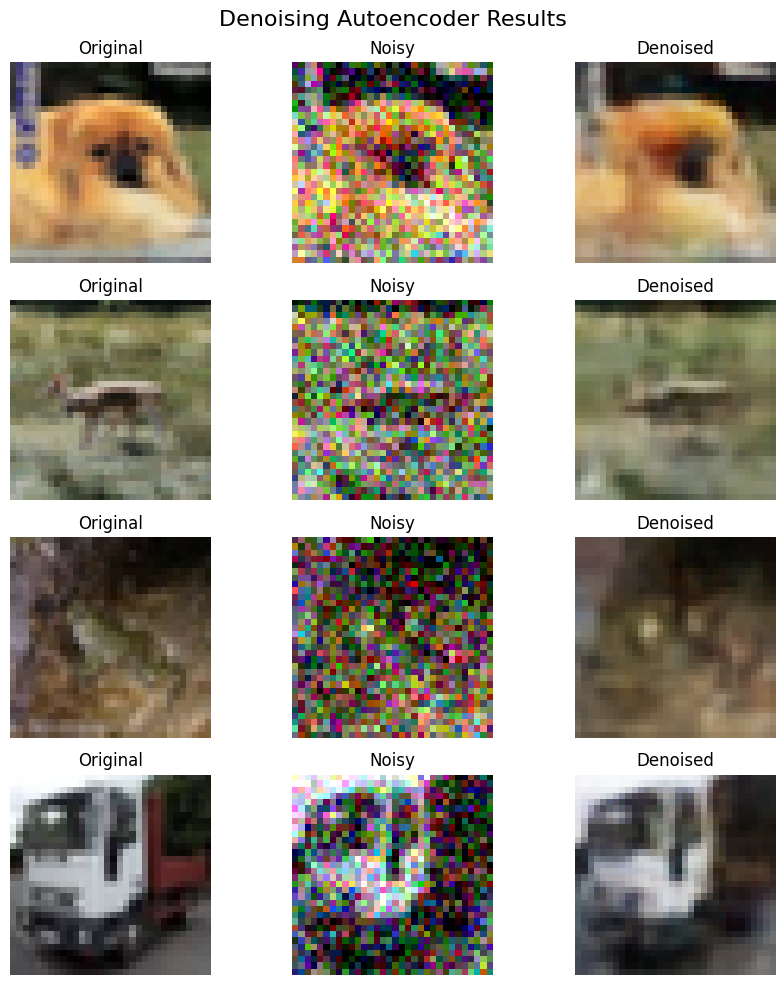

In [ ]:
model.eval()
examples = next(iter(train_loader))[0][:4].to(device)  # Take 4 images
noisy_examples = add_noise(examples)

with torch.no_grad():
    denoised = model(noisy_examples)

def show_triplet_images(originals, noisies, denoiseds, title=None):
    originals = originals.cpu().numpy().transpose(0, 2, 3, 1)
    noisies = noisies.cpu().numpy().transpose(0, 2, 3, 1)
    denoiseds = denoiseds.cpu().numpy().transpose(0, 2, 3, 1)

    n = len(originals)
    fig, axes = plt.subplots(nrows=n, ncols=3, figsize=(9, 2.5 * n))

    if title:
        fig.suptitle(title, fontsize=16)

    for i in range(n):
        axes[i, 0].imshow(originals[i])
        axes[i, 0].set_title("Original")
        axes[i, 1].imshow(noisies[i])
        axes[i, 1].set_title("Noisy")
        axes[i, 2].imshow(denoiseds[i])
        axes[i, 2].set_title("Denoised")

        for j in range(3):
            axes[i, j].axis('off')

    plt.tight_layout()
    plt.show()

# Call the new function
show_triplet_images(examples, noisy_examples, denoised, title="Denoising Autoencoder Results")
